# Infosys Springboard Internship 6.0

## AirFly Insights: Data Visualization and Analysis of Airline Operations (Milestone1)

### Project Statement:-
The objective of this project is to analyze large-scale airline flight data to uncover operational
trends, delay patterns, and cancellation reasons using data visualization techniques. The goal
is to help understand airline and airport-level performance and contribute to actionable
insights using visual analysis.

In [3]:
#Importing the libraries:-
import pandas as pd

In [4]:
#Loading the dataset:-
data=pd.read_csv('flights_sample_3m.csv')
data.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [5]:
data.shape #There are 30lakhs rows, and 32 columns
print('There are '+str(data.shape[0])+' rows and '+str(data.shape[1])+' columns in the dataset.')

There are 3000000 rows and 32 columns in the dataset.


In [6]:
pd.set_option('display.max_columns',32)
data.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [7]:
data.columns #Understanding what each column means

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

In [8]:
data.info() #Need to change the datatypes of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [9]:
#Summary Statistics:-
data.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,2.920058e+06,2.913802e+06,3.000000e+06,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,1.466511e+03,4.260858e+00,2.638000e-02,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,5.318383e+02,5.117482e+01,1.602626e-01,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,1.053000e+03,-1.600000e+01,0.000000e+00,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,1.505000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,1.913000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,2.400000e+03,2.934000e+03,1.000000e+00,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


#### Handling the null values and duplicates:-

In [10]:
data[data.duplicated()].shape #There are no duplicates, all values are unique

(0, 32)

In [11]:
data.isnull().sum() #Number of null values in each column

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [12]:
data[data['DEP_TIME'].isnull()].head() #Understanding the Nulls in columns

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
14,2020-04-07,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,687,SJC,"San Jose, CA",LAX,"Los Angeles, CA",2155,NaN,NaN,NaN,NaN,NaN,NaN,2315,NaN,NaN,1.0,D,0.0,80.0,NaN,NaN,308.0,NaN,NaN,NaN,NaN,NaN
45,2022-01-02,Republic Airline,Republic Airline: YX,YX,20452,3467,ORD,"Chicago, IL",DCA,"Washington, DC",1935,NaN,NaN,NaN,NaN,NaN,NaN,2241,NaN,NaN,1.0,B,0.0,126.0,NaN,NaN,612.0,NaN,NaN,NaN,NaN,NaN
80,2020-04-20,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,246,BNA,"Nashville, TN",ATL,"Atlanta, GA",1055,NaN,NaN,NaN,NaN,NaN,NaN,1300,NaN,NaN,1.0,D,0.0,65.0,NaN,NaN,214.0,NaN,NaN,NaN,NaN,NaN
191,2021-12-31,Alaska Airlines Inc.,Alaska Airlines Inc.: AS,AS,19930,1097,IAD,"Washington, DC",LAX,"Los Angeles, CA",1720,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,NaN,1.0,A,0.0,364.0,NaN,NaN,2288.0,NaN,NaN,NaN,NaN,NaN
236,2020-04-14,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,446,LAS,"Las Vegas, NV",HOU,"Houston, TX",500,NaN,NaN,NaN,NaN,NaN,NaN,955,NaN,NaN,1.0,D,0.0,175.0,NaN,NaN,1235.0,NaN,NaN,NaN,NaN,NaN


In [13]:
pd.set_option('display.max_rows',7000)
data[data['CANCELLATION_CODE'].isnull()].shape

(2920860, 32)

In [14]:
#Are these Cancellation Code NaN because the flights did not cancelled, need to check?
data[data['CANCELLED']==0.0].shape 
#Ok, so the fights that got cancelled does not have the cancellation_code, so replacing them with 'NC' as Not Cancelled

(2920860, 32)

In [15]:
data['CANCELLATION_CODE']=data['CANCELLATION_CODE'].fillna('NC')

In [16]:
data.isnull().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE                0
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [17]:
data[data['CRS_ELAPSED_TIME'].isnull()].head() 
#This is the scheduled elapsed time but it is not provided, so removing the nulls

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
18957,2019-01-10,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,3986,CHA,"Chattanooga, TN",ORD,"Chicago, IL",800,NaN,NaN,NaN,NaN,NaN,NaN,906,NaN,NaN,1.0,C,0.0,NaN,NaN,NaN,501.0,NaN,NaN,NaN,NaN,NaN
59252,2019-01-09,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4218,ORF,"Norfolk, VA",ORD,"Chicago, IL",1320,NaN,NaN,NaN,NaN,NaN,NaN,1453,NaN,NaN,1.0,C,0.0,NaN,NaN,NaN,717.0,NaN,NaN,NaN,NaN,NaN
300154,2019-01-07,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4356,ORD,"Chicago, IL",ROC,"Rochester, NY",1400,NaN,NaN,NaN,NaN,NaN,NaN,1645,NaN,NaN,1.0,C,0.0,NaN,NaN,NaN,528.0,NaN,NaN,NaN,NaN,NaN
339033,2019-01-08,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4153,IND,"Indianapolis, IN",ORD,"Chicago, IL",1245,NaN,NaN,NaN,NaN,NaN,NaN,1259,NaN,NaN,1.0,C,0.0,NaN,NaN,NaN,177.0,NaN,NaN,NaN,NaN,NaN
515813,2019-01-11,ExpressJet Airlines LLC d/b/a aha!,ExpressJet Airlines LLC d/b/a aha!: EV,EV,20366,4078,FSD,"Sioux Falls, SD",ORD,"Chicago, IL",1815,NaN,NaN,NaN,NaN,NaN,NaN,2005,NaN,NaN,1.0,C,0.0,NaN,NaN,NaN,462.0,NaN,NaN,NaN,NaN,NaN


In [18]:
data.dropna(subset=['CRS_ELAPSED_TIME'],inplace=True)

In [19]:
data.isnull().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77602
DEP_DELAY                    77630
TAXI_OUT                     78792
WHEELS_OFF                   78792
WHEELS_ON                    79930
TAXI_IN                      79930
CRS_ARR_TIME                     0
ARR_TIME                     79928
ARR_DELAY                    86184
CANCELLED                        0
CANCELLATION_CODE                0
DIVERTED                         0
CRS_ELAPSED_TIME                 0
ELAPSED_TIME                 86184
AIR_TIME                     86184
DISTANCE                         0
DELAY_DUE_CARRIER          2466123
DELAY_DUE_WEATHER   

In [20]:
data[(data['CANCELLATION_CODE']=='NC') & (data['ARR_DELAY']<=0) & (data['DIVERTED']==0)].shape

#These are the number of values having NaN even though the flight arrived on-time or early, so the delays needs to be filled with 0.0

(1935655, 32)

In [21]:
delays=['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
mask = ((data['CANCELLATION_CODE'] == 'NC') & (data['DIVERTED'] == 0) & (data['ARR_DELAY'] <= 0)) #Writing the conditions
data.loc[mask, delays] = data.loc[mask, delays].fillna(0.0)

#Now all the delays (reasons), if the flight did not get cancelled,and ARR_DELAY is <=0(negative values means flight arrived early), 
#as well as the flight not got diverted, all those null values should be filled with 0
#So, the flights which did not get Cancelled, Diverted and they have ARR_DELAY as negatives
#Arr_Delay=Actual Arr_Time - CRS_ARR_Time(Scheduled Time) 
#Ex:-The flight CRS_Arr_Time was 11:30 and the Actual Arr_Time was 11:00
#So, 11:00-11:30= -30mins early the flight has arrived the destination 

In [22]:
data.isnull().sum()

FL_DATE                         0
AIRLINE                         0
AIRLINE_DOT                     0
AIRLINE_CODE                    0
DOT_CODE                        0
FL_NUMBER                       0
ORIGIN                          0
ORIGIN_CITY                     0
DEST                            0
DEST_CITY                       0
CRS_DEP_TIME                    0
DEP_TIME                    77602
DEP_DELAY                   77630
TAXI_OUT                    78792
WHEELS_OFF                  78792
WHEELS_ON                   79930
TAXI_IN                     79930
CRS_ARR_TIME                    0
ARR_TIME                    79928
ARR_DELAY                   86184
CANCELLED                       0
CANCELLATION_CODE               0
DIVERTED                        0
CRS_ELAPSED_TIME                0
ELAPSED_TIME                86184
AIR_TIME                    86184
DISTANCE                        0
DELAY_DUE_CARRIER          530468
DELAY_DUE_WEATHER          530468
DELAY_DUE_NAS 

In [23]:
#Why null values in operational columns like(DEP_TIME,ARR_TIME,etc)?:- Are the flights cancelled or diverted
print('DEP_TIME:-')
print(data[data['DEP_TIME'].isna()][['CANCELLED','DIVERTED']].value_counts())
print('--'*10)

print('DEP_DELAY:-')
print(data[data['DEP_DELAY'].isna()][['CANCELLED','DIVERTED']].value_counts())
print('--'*10)

print('TAXI_OUT:-')
print(data[data['TAXI_OUT'].isna()][['CANCELLED','DIVERTED']].value_counts())
print('--'*10)

print('WHEELS_OFF:-')
print(data[data['WHEELS_OFF'].isna()][['CANCELLED','DIVERTED']].value_counts())
print('--'*10)

print('TAXI_IN:-')   #Even the Flight not cancelled and not diverted there are 2 NaN cause of this reason
print(data[data['TAXI_IN'].isna()][['CANCELLED','DIVERTED']].value_counts())
print('--'*10)


DEP_TIME:-
CANCELLED  DIVERTED
1.0        0.0         77602
Name: count, dtype: int64
--------------------
DEP_DELAY:-
CANCELLED  DIVERTED
1.0        0.0         77630
Name: count, dtype: int64
--------------------
TAXI_OUT:-
CANCELLED  DIVERTED
1.0        0.0         78792
Name: count, dtype: int64
--------------------
WHEELS_OFF:-
CANCELLED  DIVERTED
1.0        0.0         78792
Name: count, dtype: int64
--------------------
TAXI_IN:-
CANCELLED  DIVERTED
1.0        0.0         79126
0.0        1.0           802
           0.0             2
Name: count, dtype: int64
--------------------


In [24]:
pd.set_option('display.max_columns',36) #Must be the data issue so, removing this 2 rows
data[(data['TAXI_IN'].isna()) & (data['CANCELLED']==0) & (data['DIVERTED']==0)]
                                                         
#This means that the flight is not Cancelled and it has been departed from the Origin, it has also not Diverted, so it's impossible that it has not arrived.
#So, this must be some data issue, removing these two rows

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
918330,2023-05-21,Republic Airline,Republic Airline: YX,YX,20452,5612,LGA,"New York, NY",BNA,"Nashville, TN",1605,1642.0,37.0,36.0,1718.0,NaN,NaN,1746,NaN,NaN,0.0,NC,0.0,161.0,NaN,NaN,764.0,NaN,NaN,NaN,NaN,NaN
1302862,2022-12-21,Frontier Airlines Inc.,Frontier Airlines Inc.: F9,F9,20436,777,DEN,"Denver, CO",LAS,"Las Vegas, NV",1956,1951.0,-5.0,81.0,2112.0,NaN,NaN,2100,NaN,NaN,0.0,NC,0.0,124.0,NaN,NaN,628.0,NaN,NaN,NaN,NaN,NaN


In [25]:
data=data.drop(data[(data['TAXI_IN'].isna()) & (data['CANCELLED']==0) & (data['DIVERTED']==0)].index)

In [26]:
print('TAXI_IN:-')
print(data[data['TAXI_IN'].isna()][['CANCELLED','DIVERTED']].value_counts())
print('--'*10)

TAXI_IN:-
CANCELLED  DIVERTED
1.0        0.0         79126
0.0        1.0           802
Name: count, dtype: int64
--------------------


In [27]:
data.isnull().sum()

FL_DATE                         0
AIRLINE                         0
AIRLINE_DOT                     0
AIRLINE_CODE                    0
DOT_CODE                        0
FL_NUMBER                       0
ORIGIN                          0
ORIGIN_CITY                     0
DEST                            0
DEST_CITY                       0
CRS_DEP_TIME                    0
DEP_TIME                    77602
DEP_DELAY                   77630
TAXI_OUT                    78792
WHEELS_OFF                  78792
WHEELS_ON                   79928
TAXI_IN                     79928
CRS_ARR_TIME                    0
ARR_TIME                    79926
ARR_DELAY                   86182
CANCELLED                       0
CANCELLATION_CODE               0
DIVERTED                        0
CRS_ELAPSED_TIME                0
ELAPSED_TIME                86182
AIR_TIME                    86182
DISTANCE                        0
DELAY_DUE_CARRIER          530466
DELAY_DUE_WEATHER          530466
DELAY_DUE_NAS 

In [28]:
data[(data['ARR_DELAY']>0) & (data[delays].isnull().all(axis=1))].shape 

#There is arrival delay greater than 0 but the reasons(delays) are filled with NaN,Why?

(444284, 32)

In [29]:
data[(data['ARR_DELAY']>0) & (data[delays].isnull().all(axis=1))]['ARR_DELAY'].describe() 

#Here, to find the maximum delay is <15.
#So the ARR_DELAY<15mins is not considered in any type of delay reasons as per the airlines

count    444284.000000
mean          6.368163
std           3.941658
min           1.000000
25%           3.000000
50%           6.000000
75%          10.000000
max          14.000000
Name: ARR_DELAY, dtype: float64

In [30]:
data[(data['ARR_DELAY']<=15) & (data[delays].isnull().all(axis=1))].shape 

#Here, for the different delays reasons
#All the 'delays' types are having NaN values if ARR_DELAY<=15 which is same to the ARR_DELAY>0, all the ARR_DELAY>15 are filled with numbers

(444284, 32)

In [31]:
data.groupby(['CANCELLED','DIVERTED'])[delays].apply(lambda x:x.isnull().sum())

#So, replacing only the delay reasons where flights not cancelled,not diverted and ARR_DELAY<=15

DELAY_DUE_CARRIER  DELAY_DUE_WEATHER  DELAY_DUE_NAS  \
CANCELLED DIVERTED                                                        
0.0       0.0                  444284             444284         444284   
          1.0                    7056               7056           7056   
1.0       0.0                   79126              79126          79126   

                    DELAY_DUE_SECURITY  DELAY_DUE_LATE_AIRCRAFT  
CANCELLED DIVERTED                                               
0.0       0.0                   444284                   444284  
          1.0                     7056                     7056  
1.0       0.0                    79126                    79126

In [32]:
mask1=((data['CANCELLED']==0) & (data['DIVERTED']==0) & (data['ARR_DELAY']<=15))
data.loc[mask1,delays]=data.loc[mask1,delays].fillna(0.0)

In [33]:
data[delays].isnull().sum()

DELAY_DUE_CARRIER          86182
DELAY_DUE_WEATHER          86182
DELAY_DUE_NAS              86182
DELAY_DUE_SECURITY         86182
DELAY_DUE_LATE_AIRCRAFT    86182
dtype: int64

In [34]:
data.isnull().sum()

FL_DATE                        0
AIRLINE                        0
AIRLINE_DOT                    0
AIRLINE_CODE                   0
DOT_CODE                       0
FL_NUMBER                      0
ORIGIN                         0
ORIGIN_CITY                    0
DEST                           0
DEST_CITY                      0
CRS_DEP_TIME                   0
DEP_TIME                   77602
DEP_DELAY                  77630
TAXI_OUT                   78792
WHEELS_OFF                 78792
WHEELS_ON                  79928
TAXI_IN                    79928
CRS_ARR_TIME                   0
ARR_TIME                   79926
ARR_DELAY                  86182
CANCELLED                      0
CANCELLATION_CODE              0
DIVERTED                       0
CRS_ELAPSED_TIME               0
ELAPSED_TIME               86182
AIR_TIME                   86182
DISTANCE                       0
DELAY_DUE_CARRIER          86182
DELAY_DUE_WEATHER          86182
DELAY_DUE_NAS              86182
DELAY_DUE_

In [35]:
#Are there any negative values in the dataset:-
print(data[data['DEP_DELAY']<0].shape)
print(data[data['ARR_DELAY']<0].shape)

#Negative values because the Departure was early and Arrival was early
#DEP_TIME - CRS_DEP_TIME

(1787568, 32)
(1881970, 32)


In [36]:
print(data['ARR_DELAY'].describe()) #Maximum 2934mins delay for arrival and Minimum 96mins flight arrived early
print('--'*10)
print(data['DEP_DELAY'].describe()) #Maximum 2966mins delay for departure and Minimum 90mins flight took off early

count    2.913802e+06
mean     4.260858e+00
std      5.117482e+01
min     -9.600000e+01
25%     -1.600000e+01
50%     -7.000000e+00
75%      7.000000e+00
max      2.934000e+03
Name: ARR_DELAY, dtype: float64
--------------------
count    2.922354e+06
mean     1.012332e+01
std      4.925185e+01
min     -9.000000e+01
25%     -6.000000e+00
50%     -2.000000e+00
75%      6.000000e+00
max      2.966000e+03
Name: DEP_DELAY, dtype: float64


#### Converting the datatype of columns:-

In [37]:
#Converting the datatypes:-
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999984 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLATION_

In [38]:
#Changing the datatype of FL_DATE:- object to datetime
data['FL_DATE']=pd.to_datetime(data['FL_DATE'])

In [39]:
#Changing the datatype of CANCELLED and DIVERTED:- float64 to int8(smaller memory as it contains only 0 and 1)
data['CANCELLED']=data['CANCELLED'].astype('int8')
data['DIVERTED']=data['DIVERTED'].astype('int8')

In [40]:
#Converting the object to category datatype:- As these values repeats and also by converting it into cateogry it will take up less memory
catg_col=['AIRLINE','AIRLINE_DOT','AIRLINE_CODE','ORIGIN','ORIGIN_CITY','DEST','DEST_CITY','CANCELLATION_CODE']
for col in catg_col:
    data[col]=data[col].astype('category')

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999984 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int64         
 5   FL_NUMBER                int64         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             int64         
 11  DEP_TIME                 float64       
 12  DEP_DELAY                float64       
 13  TAXI_OUT                 float64       
 14  WHEELS_OFF               float64       
 15  WHEELS_ON                float64       
 16  TAXI_IN                  float64       
 17  CRS_ARR_TIME             int64  

In [42]:
#The columns which are in minutes have float64, converting them into float32, cause they have some null values as well as will use less memory
minu_col=['DEP_DELAY','ARR_DELAY','TAXI_IN','TAXI_OUT','CRS_ELAPSED_TIME','ELAPSED_TIME','AIR_TIME',
         'DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
for col in minu_col:
    data[col]=data[col].astype('float32')

In [43]:
#The columns which are in the HHMM format have datatype as int64 and float64, converting them into Int32 as they contains nulls and reduces the memory
hhmm_col=['CRS_DEP_TIME','DEP_TIME','CRS_ARR_TIME','ARR_TIME','WHEELS_OFF','WHEELS_ON']
for col in hhmm_col:
    data[col]=data[col].astype('Int32') #(Int32)? As these columns contain some nulls as well

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999984 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int64         
 5   FL_NUMBER                int64         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             Int32         
 11  DEP_TIME                 Int32         
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               Int32         
 15  WHEELS_ON                Int32         
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME             Int32  

In [45]:
#Converting distance to float32:-
data['DISTANCE']=data['DISTANCE'].astype('float32')

In [46]:
#Converting DOT_CODE and FL_NUMBER to int32 to save the memory:-
data['DOT_CODE']=data['DOT_CODE'].astype('int32')
data['FL_NUMBER']=data['FL_NUMBER'].astype('int32')

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999984 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int32         
 5   FL_NUMBER                int32         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             Int32         
 11  DEP_TIME                 Int32         
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               Int32         
 15  WHEELS_ON                Int32         
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME             Int32  

#### Feature Engineering:- Creating Derived Columns

In [48]:
#Feature Engineering:- Creating the YEAR,MONTH,MONTH_NAME,WEEKDAY from FL_DATE:-
data['YEAR']=data['FL_DATE'].dt.year
data['MONTH']=data['FL_DATE'].dt.month
data['MONTH_NAME']=data['FL_DATE'].dt.month_name()
data['WEEKDAY']=data['FL_DATE'].dt.day_name()

In [49]:
data.isnull().sum()

FL_DATE                        0
AIRLINE                        0
AIRLINE_DOT                    0
AIRLINE_CODE                   0
DOT_CODE                       0
FL_NUMBER                      0
ORIGIN                         0
ORIGIN_CITY                    0
DEST                           0
DEST_CITY                      0
CRS_DEP_TIME                   0
DEP_TIME                   77602
DEP_DELAY                  77630
TAXI_OUT                   78792
WHEELS_OFF                 78792
WHEELS_ON                  79928
TAXI_IN                    79928
CRS_ARR_TIME                   0
ARR_TIME                   79926
ARR_DELAY                  86182
CANCELLED                      0
CANCELLATION_CODE              0
DIVERTED                       0
CRS_ELAPSED_TIME               0
ELAPSED_TIME               86182
AIR_TIME                   86182
DISTANCE                       0
DELAY_DUE_CARRIER          86182
DELAY_DUE_WEATHER          86182
DELAY_DUE_NAS              86182
DELAY_DUE_

In [50]:
#Extracting the hour of departure:-
data['DEP_HOUR']=data['DEP_TIME']//100
data['DEP_HOUR']=data['DEP_HOUR'].fillna(data['CRS_DEP_TIME']//100)
data['DEP_HOUR']=data['DEP_HOUR'].astype('Int8') 

#As the hours are from 0-23 :. Int8 will take less memory

In [51]:
#Creating the Route column:-
data['ROUTE']=data['ORIGIN'].astype(str)+'-'+data['DEST'].astype(str)
data['ROUTE']=data['ROUTE'].astype('category')

In [52]:
#Changing the datatypes of YEAR, MONTH, MONTH_NAME, WEEKDAY:-
data['YEAR']=data['YEAR'].astype('int32')
data['MONTH']=data['MONTH'].astype('int8')
data['MONTH_NAME']=data['MONTH_NAME'].astype('category')
data['WEEKDAY']=data['WEEKDAY'].astype('category')

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999984 entries, 0 to 2999999
Data columns (total 38 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int32         
 5   FL_NUMBER                int32         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             Int32         
 11  DEP_TIME                 Int32         
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               Int32         
 15  WHEELS_ON                Int32         
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME             Int32  

In [54]:
data.head(10)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YEAR,MONTH,MONTH_NAME,WEEKDAY,DEP_HOUR,ROUTE
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151,-4.0,19.0,1210,1443,4.0,1501,...,0,NC,0,186.0,176.0,153.0,1065.0,0.0,0.0,0.0,0.0,0.0,2019,1,January,Wednesday,11,FLL-EWR
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114,-6.0,9.0,2123,2232,38.0,2315,...,0,NC,0,235.0,236.0,189.0,1399.0,0.0,0.0,0.0,0.0,0.0,2022,11,November,Saturday,21,MSP-SEA
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000,6.0,20.0,1020,1247,5.0,1252,...,0,NC,0,118.0,112.0,87.0,680.0,0.0,0.0,0.0,0.0,0.0,2022,7,July,Friday,10,DEN-MSP
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608,-1.0,27.0,1635,1844,9.0,1829,...,0,NC,0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0,2023,3,March,Monday,16,MSP-SFO
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838,-2.0,15.0,1853,2026,14.0,2041,...,0,NC,0,181.0,182.0,153.0,985.0,0.0,0.0,0.0,0.0,0.0,2020,2,February,Sunday,18,MCO-DFW
5,2019-07-31,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,665,DAL,"Dallas, TX",OKC,"Oklahoma City, OK",1010,1237,147.0,15.0,1252,1328,3.0,1110,...,0,NC,0,60.0,54.0,36.0,181.0,141.0,0.0,0.0,0.0,0.0,2019,7,July,Wednesday,12,DAL-OKC
6,2023-06-11,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2134,DCA,"Washington, DC",BOS,"Boston, MA",1010,1001,-9.0,23.0,1024,1122,8.0,1159,...,0,NC,0,109.0,89.0,58.0,399.0,0.0,0.0,0.0,0.0,0.0,2023,6,June,Sunday,10,DCA-BOS
7,2019-07-08,Republic Airline,Republic Airline: YX,YX,20452,4464,HSV,"Huntsville, AL",DCA,"Washington, DC",1643,1637,-6.0,22.0,1659,1927,41.0,1945,...,0,NC,0,122.0,151.0,88.0,613.0,0.0,0.0,23.0,0.0,0.0,2019,7,July,Monday,16,HSV-DCA
8,2023-02-12,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,590,IAH,"Houston, TX",LAX,"Los Angeles, CA",530,527,-3.0,11.0,538,658,8.0,717,...,0,NC,0,227.0,219.0,200.0,1379.0,0.0,0.0,0.0,0.0,0.0,2023,2,February,Sunday,5,IAH-LAX
9,2020-08-22,Alaska Airlines Inc.,Alaska Airlines Inc.: AS,AS,19930,223,SEA,"Seattle, WA",FAI,"Fairbanks, AK",2125,2116,-9.0,19.0,2135,2353,3.0,2355,...,0,NC,0,210.0,220.0,198.0,1533.0,0.0,0.0,0.0,0.0,0.0,2020,8,August,Saturday,21,SEA-FAI


In [55]:
#Columns which has null values which are operational/structured null values because of the CANCELLED/DIVERTED flights
print('Number of Nulls in each column:-')
print(' ')
data.groupby(['CANCELLED','DIVERTED'])[['DEP_TIME','TAXI_OUT','WHEELS_OFF','DEP_DELAY','ARR_TIME','TAXI_IN','WHEELS_ON','ARR_DELAY','ELAPSED_TIME','AIR_TIME']].apply(lambda x:x.isnull().sum())

Number of Nulls in each column:-
 


DEP_TIME  TAXI_OUT  WHEELS_OFF  DEP_DELAY  ARR_TIME  \
CANCELLED DIVERTED                                                        
0         0                0         0           0          0         0   
          1                0         0           0          0       800   
1         0            77602     78792       78792      77630     79126   

                    TAXI_IN  WHEELS_ON  ARR_DELAY  ELAPSED_TIME  AIR_TIME  
CANCELLED DIVERTED                                                         
0         0               0          0          0             0         0  
          1             802        802       7056          7056      7056  
1         0           79126      79126      79126         79126     79126

In [56]:
print('After the cleaning and preprocessing of the dataset. There are '+str(data.shape[0])+' rows and '+str(data.shape[1])+'columns.')

After the cleaning and preprocessing of the dataset. There are 2999984 rows and 38columns.


#### Saving the dataset:-

In [57]:
#Saving the cleaned dataset for further analysis:-
data.to_csv('cleaned_flights_sample.csv',index=False)

## Summary of Preprocessing the Dataset:- 
1. Data Understanding:-<br>
   a. Reviewed dataset structure, column definitions, shape and data types. <br>
   b. Confirmed 0 duplicate rows in the dataset, so each record represents a unique fligt.<br>
   
2. Handling Missing Values:-<br>
   a. Replaced the nulls in CANCELLATION_CODE(2920860) with 'NC' as null indicated flights were not cancelled.<br>
   b. Removed rows with missing CRS_ELAPSED_TIME(14) since the scheduled time should always exist, so that must be the data issue.<br>
   c. Replaced NaN values in delay reason columns(1935655) with 0.0 as these coresponded to on-time,early flights.<br>
   d. Identified and removed 2 logically inconsistent rows in TAXI_IN.<br>
   e. Replaced NaN values in dealy reasons columns(444284) with 0.0 as they were corresponded to minor delays considered by airlines (<=15 mins).<br>

3. Operational Nulls/Structured Nulls:-<br>
   a. There are null values in columns such as DEP_TIME,ARR_TIME,etc and all the delay reasons, where flights were cancelled or diverted.<br>
   b. These are structural nulls and were preserved to maintain data integrity.<br>

4. Data Validation:-<br>
   a. Verified negative delay values in the DEP_DELAY and ARR_DELAY represents early departures/arrivals.<br>

5. Feature Engineering:-<br>
   a. Extracted YEAR, MONTH, MONTH_NAME from FL_DATE.<br>
   b. Derived DEP_HOUR from DEP_TIME and CRS_DEP_TIME.<br>
   c. Created ROUTE feature combining origin and destination.<br>
Note:-Null values represented events that never occurred due to cancellations or diversions. Replacing them with zero would introduce misleading operational interpretations, so they were retained to preserve data integrity.

#### KPI's (Key Performance Indicators):-

In [58]:
#Total flight records:-
total_flights=data['FL_NUMBER'].count()
print('Total Flights: ',total_flights)

#Number of unique airlines:-
unique_airlines=data['AIRLINE'].nunique()
print('Unique Airlines: ',unique_airlines)

#Percentage of flights that got cancelled:-
cancelled_flights=round(((data['CANCELLED']==1).sum()/len(data))*100,2)
print(f'Cancelled Flights: {cancelled_flights:.2f}%')

#Percentage of flights that got diverted:-
diverted_flights=round(((data['DIVERTED']==1).sum()/len(data))*100,2)
print(f'Diverted Flights: {diverted_flights:.2f}%')

#Percentage of late departed flights:-
per_late_dep=round(((data['DEP_DELAY']>0).sum()/data['DEP_DELAY'].notna().sum())*100,2)
print(f'Percentage of Late Departed Flights: {per_late_dep:.2f}%')

#Average Late Departure Delay:-
avg_latedep=round(data[(data['CANCELLED']==0) & (data['DEP_DELAY']>0)]['DEP_DELAY'].mean(),2)
print('Average Late Departure Delay: ',avg_latedep)

#Average Late Arrival Delay:-
avg_latearr=round(data[(data['CANCELLED']==0) & (data['ARR_DELAY']>0)]['ARR_DELAY'].mean(),2)
print('Average Late Arrival Delay: ',avg_latearr)


Total Flights:  2999984
Unique Airlines:  18
Cancelled Flights: 2.64%
Diverted Flights: 0.24%
Percentage of Late Departed Flights: 33.97%
Average Late Departure Delay:  39.46
Average Late Arrival Delay:  39.75


### Univariate, Bivariate Analysis and Delay Analysis:-

In [59]:
#Importing all the libraries:-
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999984 entries, 0 to 2999999
Data columns (total 38 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int32         
 5   FL_NUMBER                int32         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             Int32         
 11  DEP_TIME                 Int32         
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               Int32         
 15  WHEELS_ON                Int32         
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME             Int32  

#### Percentage of Cancelled VS Not Cancelled flights:-

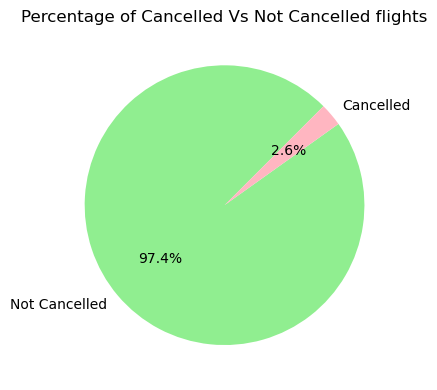

From the above chart, Not Cancelled flights are 97.4% and Cancelled flights are 2.6%.


In [61]:
cancel_counts=data['CANCELLED'].value_counts()
labels=['Not Cancelled','Cancelled']
plt.figure(figsize=(6,4))
plt.pie(cancel_counts,labels=labels,autopct='%1.1f%%',startangle=45,colors=['lightgreen','lightpink'])
plt.title('Percentage of Cancelled Vs Not Cancelled flights')
plt.tight_layout()
plt.savefig('CancelledVSNotCancelled.png', dpi=300, bbox_inches='tight')
plt.show()
print('From the above chart, Not Cancelled flights are 97.4% and Cancelled flights are 2.6%.')

In [62]:
#Analysing the flights which take off as well as they are not diverted, means they reach at their destination
active_flights=data[(data['CANCELLED']==0) & (data['DIVERTED']==0)]
len(active_flights)

2913802

#### Top Airlines by Number of flights (not cancelled and not diverted):-

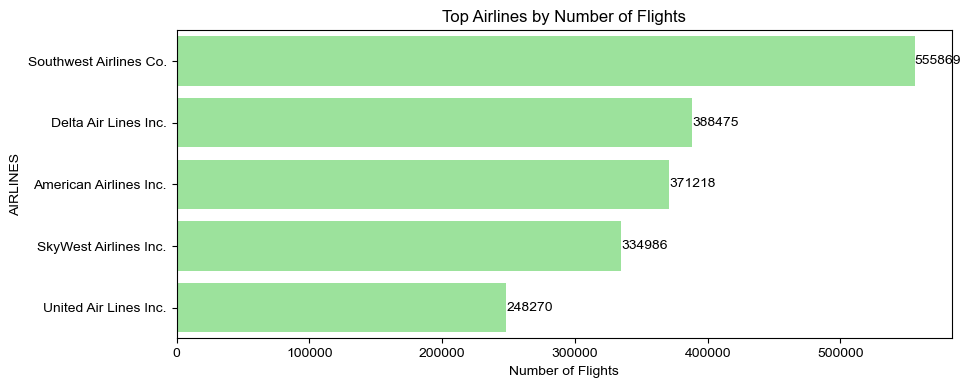

The above chart shows the Top 5 Airlines in the dataset with Southwest Airlines Co. at the top with ~5 lakhs flights.


In [63]:
top_airlines=active_flights['AIRLINE'].value_counts().head(5)
plt.figure(figsize=(10,4))
i=sns.barplot(x=top_airlines.values,y=top_airlines.index,order=top_airlines.index,color='lightgreen')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('Number of Flights')
plt.ylabel('AIRLINES')
plt.title('Top Airlines by Number of Flights')
sns.set_style('white')
plt.show()
print('The above chart shows the Top 5 Airlines in the dataset with Southwest Airlines Co. at the top with ~5 lakhs flights.')

#### Busiest Months:-

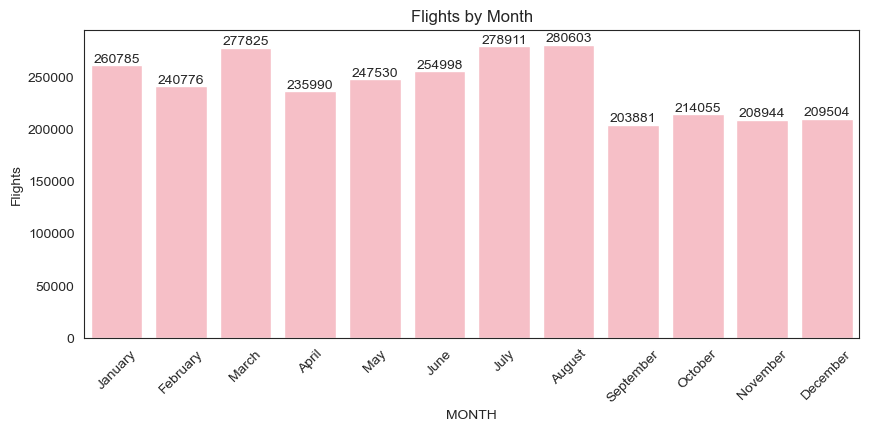

The bar chart shows that the month of August, July and March were the busiest months and September with least flights.


In [64]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
month_counts=active_flights['MONTH_NAME'].value_counts().reindex(month_order)
plt.figure(figsize=(10,4))
i=sns.barplot(x=month_counts.index,y=month_counts.values,color='lightpink')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Flights by Month')
plt.xlabel('MONTH')
plt.ylabel('Flights')
plt.xticks(rotation=45)
plt.show()
print('The bar chart shows that the month of August, July and March were the busiest months and September with least flights.')

#### Year with most flights:-

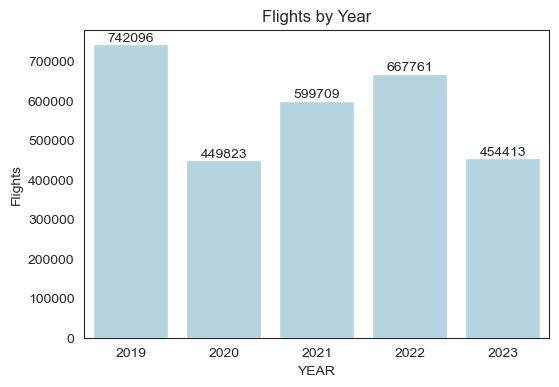

The year 2019 was having the most flights (~7 lakh flights), 2020 and 2023 were having the least number of flights that took off.


In [65]:
year_counts=active_flights['YEAR'].value_counts().sort_index()
plt.figure(figsize=(6,4))
i=sns.barplot(x=year_counts.index,y=year_counts.values,color='lightblue')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Flights by Year')
plt.xlabel('YEAR')
plt.ylabel('Flights')
plt.show()
print('The year 2019 was having the most flights (~7 lakh flights), 2020 and 2023 were having the least number of flights that took off.')

#### Busiest Weekday:-

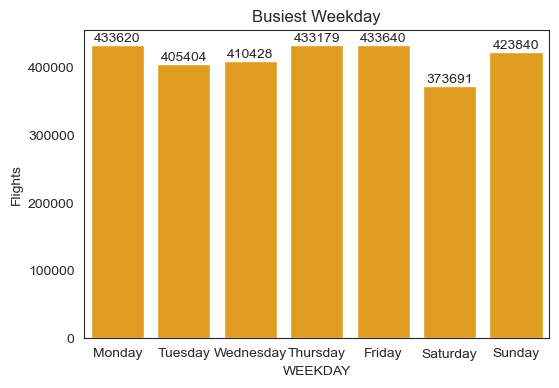

The busisest weekday is Friday, Monday and  Thursday, the month which was not that busy is Saturday.


In [66]:
weekday_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts=active_flights['WEEKDAY'].value_counts().sort_index()
plt.figure(figsize=(6,4))
i=sns.barplot(x=weekday_counts.index,y=weekday_counts.values,order=weekday_order,color='orange')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Busiest Weekday')
plt.xlabel('WEEKDAY')
plt.ylabel('Flights')
plt.show()
print('The busisest weekday is Friday, Monday and  Thursday, the month which was not that busy is Saturday.')

##### ALL the above charts shows the flights which were not cancelled and not diverted, basically means they took off and landed at their scheduled destination.

#### What are the reasons for delay?

#### Top 10 Airlines which got most delayed flights:-

In [67]:
delayed_flights=active_flights[active_flights['ARR_DELAY']>0]  #The delayed flights, arr_delay>0

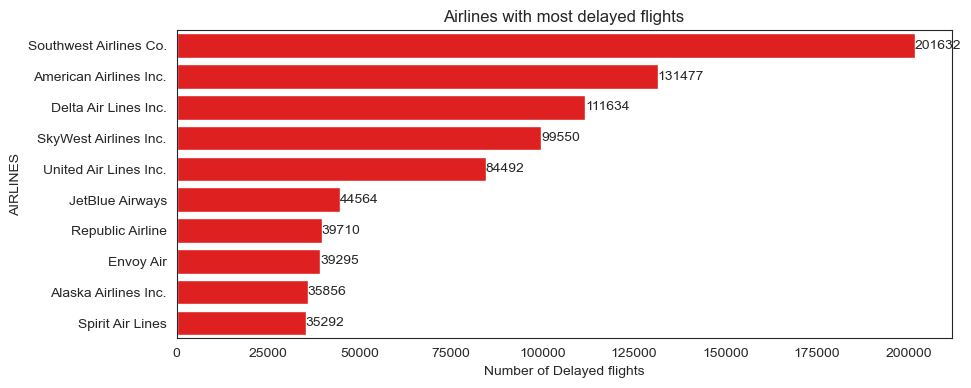

Southwest Airlines Co. is the Airline with most delays.


In [68]:
delayed_airlines=delayed_flights['AIRLINE'].value_counts().head(10)
plt.figure(figsize=(10,4))
i=sns.barplot(x=delayed_airlines.values,y=delayed_airlines.index,order=delayed_airlines.index,color='red')
plt.xlabel('Number of Delayed flights')
plt.ylabel('AIRLINES')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Airlines with most delayed flights')
plt.show()
print('Southwest Airlines Co. is the Airline with most delays.')

#### Average Delay by the Airlines (in mins):-

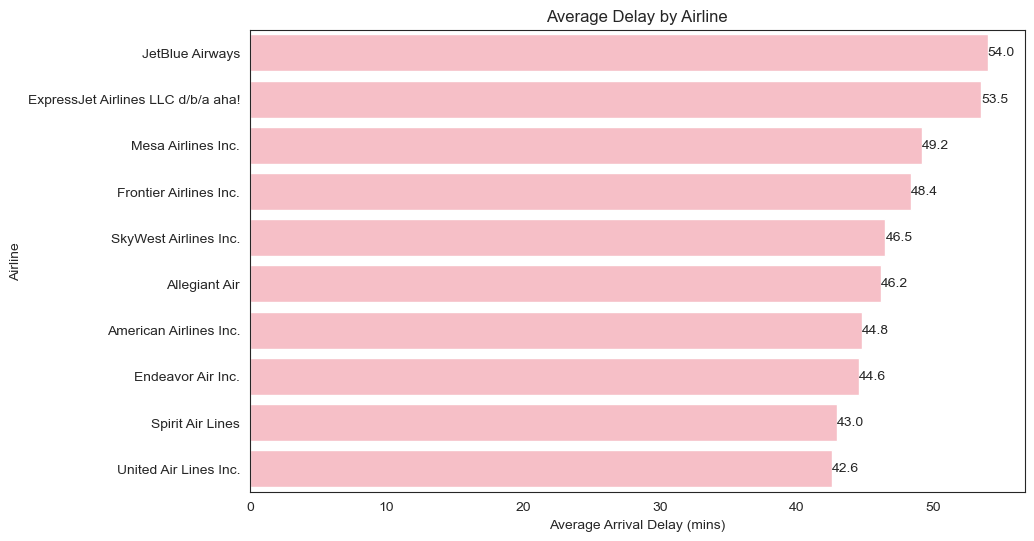

The Average delay is maximum for JetBlue Airways and Express.Jet Airlines LLC d/b/a aha! with delay of 54.0 mins and 53.5 mins.


In [69]:
avg_delay_airline = delayed_flights.groupby('AIRLINE',observed=True)['ARR_DELAY'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
i=sns.barplot(x=avg_delay_airline.values, y=avg_delay_airline.index,order=avg_delay_airline.index,color='lightpink')
for bars in i.containers:
    i.bar_label(bars,fmt='%1.1f')
plt.xlabel("Average Arrival Delay (mins)")
plt.ylabel("Airline")
plt.title("Average Delay by Airline")
plt.show()
print('The Average delay is maximum for JetBlue Airways and Express.Jet Airlines LLC d/b/a aha! with delay of 54.0 mins and 53.5 mins.')

#### Average Delay by Reasons:-

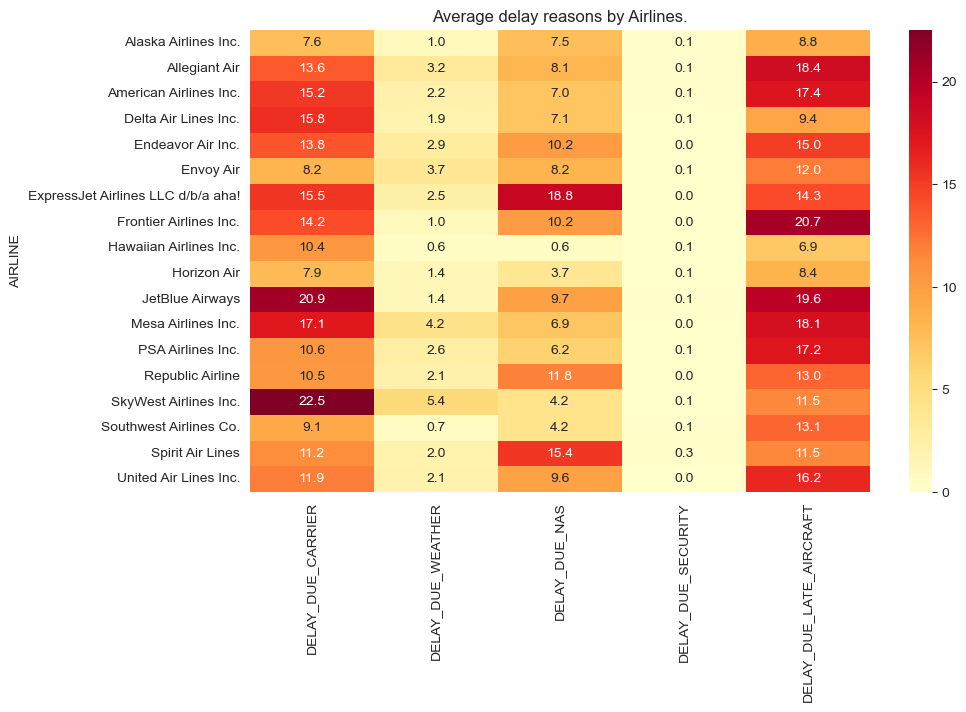

As we know that JetBlue Airways has maximum avg delay, most delay is due to the Carrier and late aircraft, SkyWest Airlines also was delayed the most because of Carrier, Express.Jet Airlines LLC d/b/a aha! has the most delays due to NAS the reason must be air traffic and congestion and Frontier Airlines Inc. delayed the most due to late aircraft.


In [70]:
delay_reason_airline=delayed_flights.groupby('AIRLINE',observed=True)[['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']].mean()
plt.figure(figsize=(10,6))
sns.heatmap(delay_reason_airline,cmap='YlOrRd',annot=True,fmt='.1f')
plt.title('Average delay reasons by Airlines.')
plt.show()
print('As we know that JetBlue Airways has maximum avg delay, most delay is due to the Carrier and late aircraft, SkyWest Airlines also was delayed the most because of Carrier, Express.Jet Airlines LLC d/b/a aha! has the most delays due to NAS the reason must be air traffic and congestion and Frontier Airlines Inc. delayed the most due to late aircraft.')

#### Airlines with more diversions:-

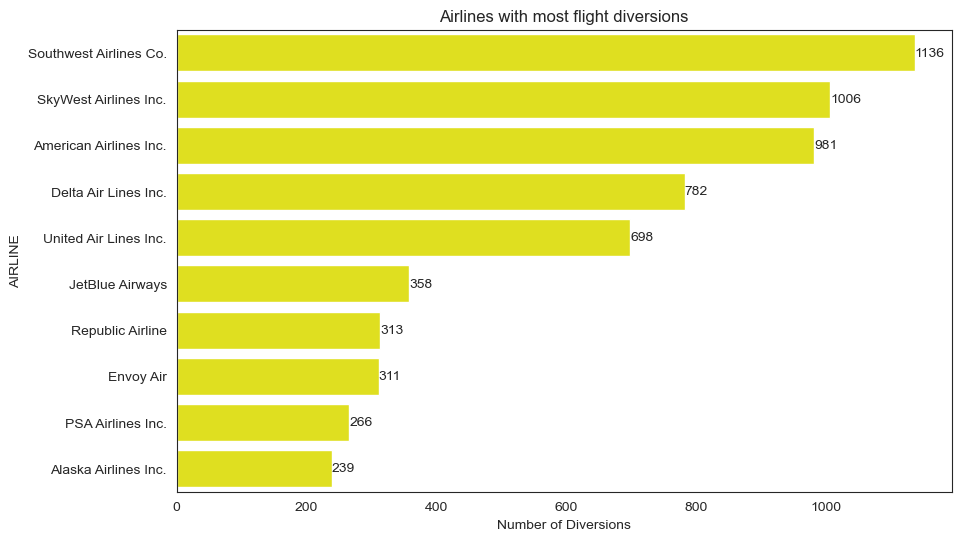

The above chart shows the airlines whose flights diverted the most, did not landed at the scheduled airport.


In [71]:
diverted_airlines=data[data['DIVERTED']==1]['AIRLINE'].value_counts().head(10)
plt.figure(figsize=(10,6))
i=sns.barplot(x=diverted_airlines.values,y=diverted_airlines.index,order=diverted_airlines.index,color='yellow')
plt.xlabel('Number of Diversions')
plt.ylabel('AIRLINE')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Airlines with most flight diversions')
plt.show()
print('The above chart shows the airlines whose flights diverted the most, did not landed at the scheduled airport.')

In [72]:
active_flights['ROUTE']=active_flights['ROUTE'].astype('str')

#### Most Visited Routes:-

In [73]:
top_dest=(active_flights['ROUTE'].value_counts().nlargest(5).reset_index())
top_dest.columns=['ROUTE','COUNT']
top_dest

,ROUTE,COUNT
0,SFO-LAX,5218
1,LAX-SFO,5072
2,OGG-HNL,4589
3,LAX-LAS,4540
4,LGA-ORD,4510


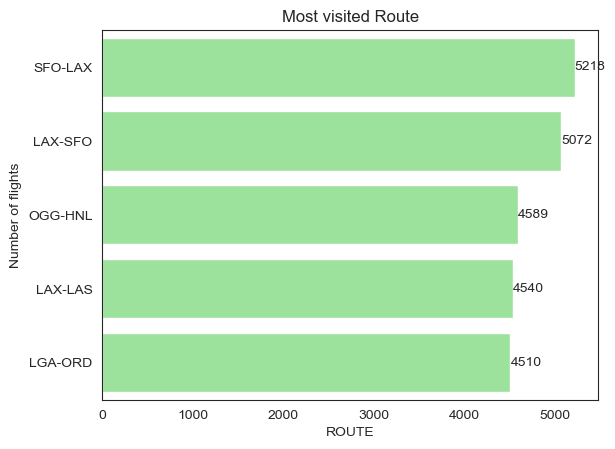

Route SFO-LAX and LAX-SFO is the most visited route. SFO(San Francisco) and LAX(Los Angeles)


In [74]:
i=sns.barplot(x='COUNT',y='ROUTE',data=top_dest,color='lightgreen')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('ROUTE')
plt.ylabel('Number of flights')
plt.title('Most visited Route')
plt.show()
print('Route SFO-LAX and LAX-SFO is the most visited route. SFO(San Francisco) and LAX(Los Angeles)')

### Route, Airport-Level, Seasonal and Cancellation Analysis:-

### Top-10 most Delayed Routes:-

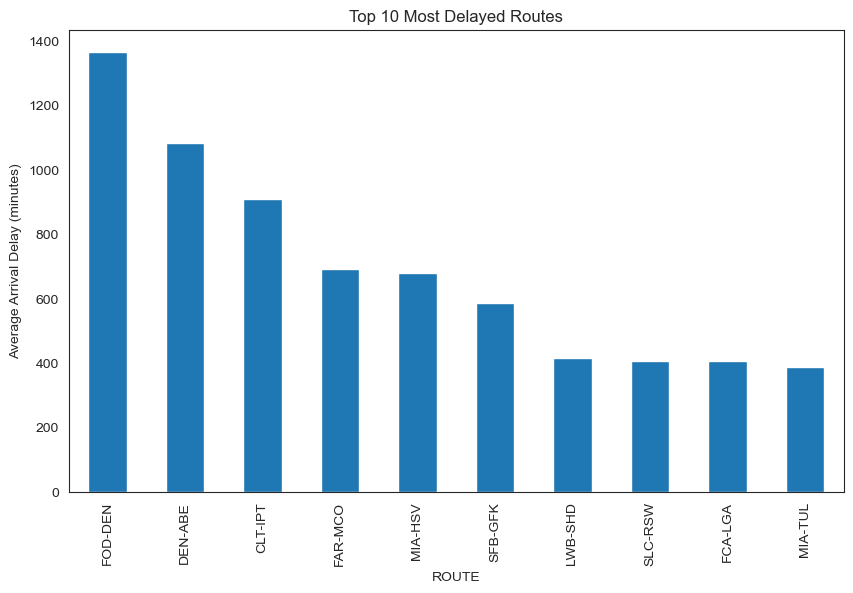

In [75]:
delayed_flights=active_flights[active_flights['ARR_DELAY']>0]  #The delayed flights, arr_delay>0
route_delay = delayed_flights.groupby('ROUTE')['ARR_DELAY'].mean().sort_values(ascending=False)

route_delay.head(10).plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Most Delayed Routes')
plt.ylabel('Average Arrival Delay (minutes)')
plt.show()


### Top-10 Delayed Routes with Delayed Reasons:-

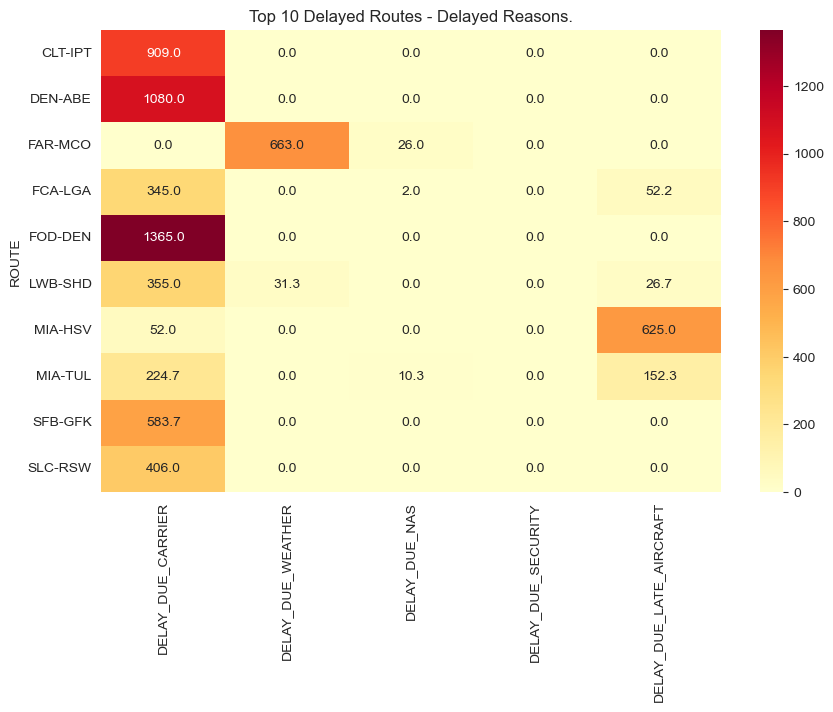

Top 10 Delayed routes with delayed reasons, FOD-DEN, DEN-ABE,CLT-IPT are the Routes with maximum delay_due_carrier, FAR-MCO route was delayed cause of weather.


In [76]:
top_routes = route_delay.head(10).index
top_delayed_data = delayed_flights[delayed_flights['ROUTE'].isin(top_routes)]
delay_reason_airline=top_delayed_data.groupby('ROUTE',observed=True)[['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']].mean()
plt.figure(figsize=(10,6))
sns.heatmap(delay_reason_airline,cmap='YlOrRd',annot=True,fmt='.1f')
plt.title('Top 10 Delayed Routes - Delayed Reasons.')
plt.show()
print('Top 10 Delayed routes with delayed reasons, FOD-DEN, DEN-ABE,CLT-IPT are the Routes with maximum delay_due_carrier, FAR-MCO route was delayed cause of weather.')

### Bussiest Airports (Origin based Airports):-

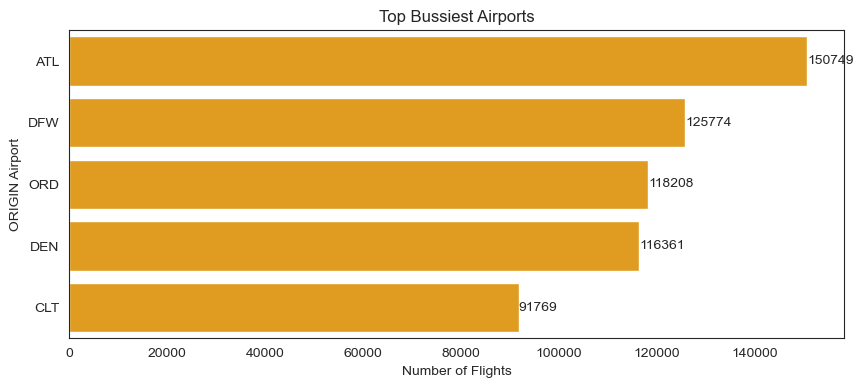

Above chart shows the bussiest Origin Airports.


In [77]:
top_airports=active_flights['ORIGIN'].value_counts().head(5)
plt.figure(figsize=(10,4))
i=sns.barplot(x=top_airports.values,y=top_airports.index,order=top_airports.index,color='orange')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('Number of Flights')
plt.ylabel('ORIGIN Airport')
plt.title('Top Bussiest Airports')
sns.set_style('white')
plt.show()
print('Above chart shows the bussiest Origin Airports.')

### Average Departure and Arrival Delay by Airlines:-

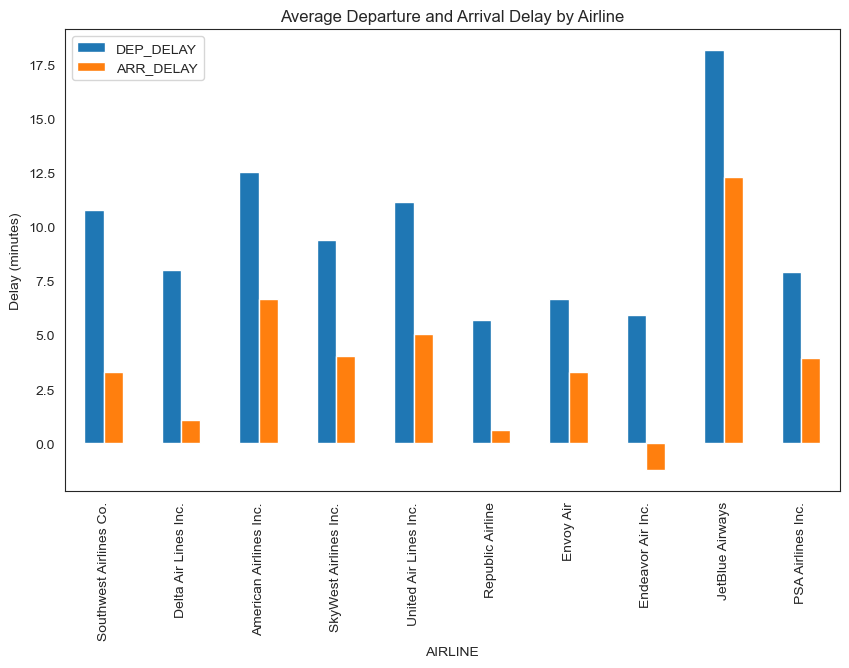

Avg DEP_DELAY is greater than ARR_DELAY. So, flights depart late but arrive with less delay which means airlines try to make up the time during journey.


In [78]:
airline_delay = active_flights.groupby('AIRLINE').agg({
    'DEP_DELAY': 'mean',
    'ARR_DELAY': 'mean'
}).sort_values('ARR_DELAY', ascending=False)

top_airlines = active_flights['AIRLINE'].value_counts().head(10).index
airline_delay_top = airline_delay.loc[top_airlines]

airline_delay_top.plot(kind='bar', figsize=(10,6))
plt.title('Average Departure and Arrival Delay by Airline')
plt.ylabel('Delay (minutes)')
plt.show()
print('Avg DEP_DELAY is greater than ARR_DELAY. So, flights depart late but arrive with less delay which means airlines try to make up the time during journey.')

In [79]:
#Cancelled flights:-
cancelled_flights=data[data['CANCELLED']==True]
len(cancelled_flights)

79126

### Average Cancellation of Flights by Month:-

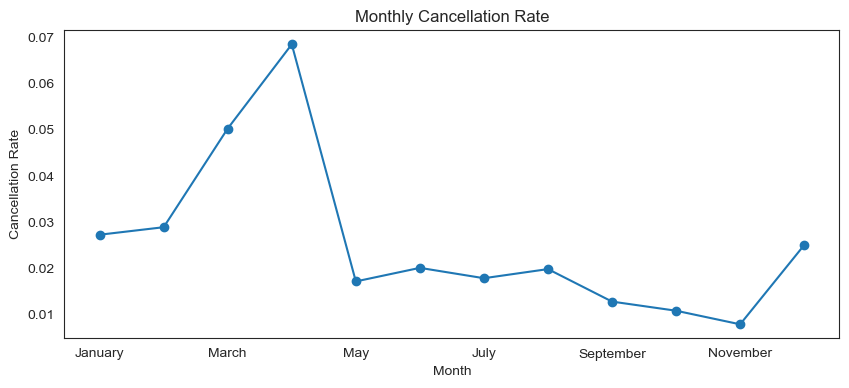

The flights cancellation rate is maximum in March and April and less in the month of November


In [80]:
#Avg Cancellation of flights in each month
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_count=data.groupby('MONTH_NAME')['CANCELLED'].mean().reindex(month_order)

plt.figure(figsize=(10,4))
monthly_count.plot(kind='line',marker='o')
plt.title('Monthly Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.show()

print('The flights cancellation rate is maximum in March and April and less in the month of November')

### Cancellation Types for Cancelled flights:-

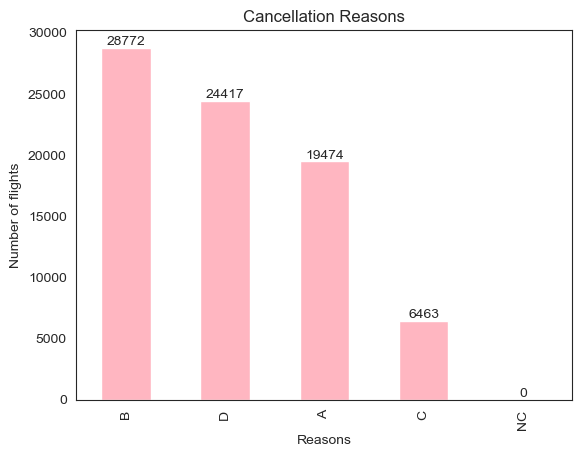

Here, A=Carrier, B=Weather, C=NAS, D=Security and NC is Not Cancelled. So, most of the flights got cancelled due to the Weather issues and Security issues.


In [81]:
#Cancellation types:-
cancel_types=cancelled_flights['CANCELLATION_CODE'].value_counts()
i=cancel_types.plot(kind='bar',color='lightpink')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Cancellation Reasons')
plt.xlabel('Reasons')
plt.ylabel('Number of flights')
plt.show()

print('Here, A=Carrier, B=Weather, C=NAS, D=Security and NC is Not Cancelled. So, most of the flights got cancelled due to the Weather issues and Security issues.' )

### Impact of Holidays in the Month of November and December:-

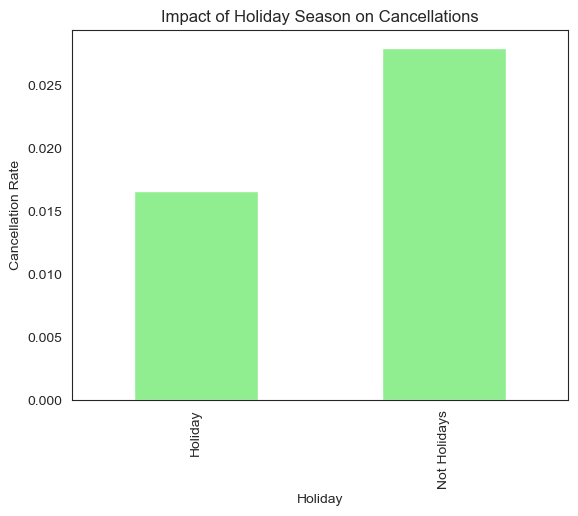

From the above chart, the cancellation rates during the holiday months are lower than the not holidays.


In [82]:
data['Holiday']=data['MONTH'].apply(lambda x: 'Holiday' if x in [11,12] else 'Not Holidays')
holiday_impact=data.groupby('Holiday')['CANCELLED'].mean()
holiday_impact.plot(kind='bar',color='lightgreen')
plt.title('Impact of Holiday Season on Cancellations')
plt.ylabel('Cancellation Rate')
plt.show()
print('From the above chart, the cancellation rates during the holiday months are lower than the not holidays.')

##### The analysis of airline operations reveals that overall performance remains stable, with a low cancellation rate of approximately 2.6%, indicating that the majority of flights operate as scheduled. Among all airlines, Southwest Airlines dominates in terms of flight volume, operating the highest number of flights.
##### Flight demand shows clear seasonal patterns, with peak activity observed during July, August, and March, while September records the lowest traffic.Additionally, weekdays such as Friday, Monday, and Thursday experience higher travel activity, whereas Saturdays are comparatively less busy.
##### In terms of operational performance, JetBlue Airways and ExpressJet Airlines report the highest average arrival delays, with delays exceeding 50 minutes. It is also observed that departure delays are generally higher than arrival delays, suggesting that airlines are able to recover some lost time during transit.
##### Delay analysis further indicates that carrier-related issues are the primary cause of delays, followed by NAS (air traffic congestion), weather conditions, and late aircraft delays. Although flight diversions are relatively rare (~0.23%), airlines such as Southwest and SkyWest show slightly higher instances compared to others.
##### Route-level analysis highlights that the SFO–LAX and LAX–SFO routes are the most frequently traveled, indicating strong demand between major city pairs. However, certain routes such as FOD–DEN and DEN–ABE experience higher delays, mainly due to operational and carrier-related factors. Additionally, major airports such as ATL, DFW, and ORD emerge as the busiest hubs.
##### From a disruption perspective, flight cancellations peak during March and April, while November records the lowest cancellation rates. The primary causes of cancellations are identified as weather and security-related issues. Interestingly, cancellation rates during holiday months such as November and December are relatively lower, suggesting improved operational stability during peak travel periods.

#### Note:- The dataset still contains null values in columns such as DEP_DELAY, DEP_TIME, TAXI_IN, TAXI_OUT, WHEELS_ON, and WHEELS_OFF. These missing values are primarily associated with cancelled or diverted flights, where actual flight operations did not occur. The dataset still contains null values in columns such as DepDelay, DepTime, TaxiIn, TaxiOut, WheelsOn, and WheelsOff. These missing values are primarily associated with cancelled or diverted flights, where actual flight operations did not occur.